### Plantix - Plant Disease Prediction

In [88]:
# Importing libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, Rescaling, RandomFlip, RandomRotation, RandomZoom, RandomContrast #type: ignore
from tensorflow.keras.models import Sequential #type: ignore
from tensorflow.keras.regularizers import l2 #type: ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau #type: ignore
import json
from sklearn.metrics import classification_report, confusion_matrix

##### Data Preprocessing

In [24]:
training_set = tf.keras.utils.image_dataset_from_directory(
    "C:/Users/Aadarsh/Desktop/Plantix/data/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


In [25]:
# Validation image preprocessing
validation_set = tf.keras.utils.image_dataset_from_directory(
    "C:/Users/Aadarsh/Desktop/Plantix/data/valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [26]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [27]:
validation_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [28]:
for x, y in training_set:
    print(x.shape)
    print(y.shape)
    break

(32, 128, 128, 3)
(32, 38)


##### Building Model

In [29]:
model = tf.keras.models.Sequential()

In [ ]:
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=[128,128,3])) #type: ignore
model.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [ ]:
model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [ ]:
model.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [ ]:
model.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=256, kernel_size=3, activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [ ]:
model.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=512, kernel_size=3, activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

In [35]:
model.add(tf.keras.layers.Dropout(0.25))

In [36]:
model.add(tf.keras.layers.Flatten())

In [ ]:
model.add(tf.keras.layers.Dense(units=1500, activation='relu'))

In [38]:
model.add(tf.keras.layers.Dropout(0.4)) #To avoid overfitting

In [ ]:
# Output layer
model.add(tf.keras.layers.Dense(units=38, activation='softmax'))

##### Compiling Model

In [40]:
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

In [41]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_10 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 conv2d_11 (Conv2D)          (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_12 (Conv2D)          (None, 63, 63, 64)        18496     
                                                                 
 conv2d_13 (Conv2D)          (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                  

In [42]:
for x, y in training_set.take(1):
    print(x.numpy().min(), x.numpy().max(), x.numpy().mean())

0.0 255.0 121.469124


##### Training Model

In [43]:
training_history = model.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=10
)

Epoch 1/10
2197/2197 [==============================] - 190s 86ms/step - loss: 1.4417 - accuracy: 0.5788 - val_loss: 0.5094 - val_accuracy: 0.8333
Epoch 2/10
2197/2197 [==============================] - 193s 88ms/step - loss: 0.4665 - accuracy: 0.8518 - val_loss: 0.3032 - val_accuracy: 0.9054
Epoch 3/10
2197/2197 [==============================] - 192s 87ms/step - loss: 0.2802 - accuracy: 0.9107 - val_loss: 0.1871 - val_accuracy: 0.9391
Epoch 4/10
2197/2197 [==============================] - 193s 88ms/step - loss: 0.1891 - accuracy: 0.9377 - val_loss: 0.1626 - val_accuracy: 0.9462
Epoch 5/10
2197/2197 [==============================] - 193s 88ms/step - loss: 0.1406 - accuracy: 0.9538 - val_loss: 0.1207 - val_accuracy: 0.9611
Epoch 6/10
2197/2197 [==============================] - 193s 88ms/step - loss: 0.1085 - accuracy: 0.9650 - val_loss: 0.1491 - val_accuracy: 0.9535
Epoch 7/10
2197/2197 [==============================] - 196s 89ms/step - loss: 0.0899 - accuracy: 0.9703 - val_loss: 0

##### Model Evaluation

In [48]:
# Model evaluation on training set
training_loss, training_accuracy = model.evaluate(training_set)

2197/2197 [==============================] - 56s 25ms/step - loss: 0.0489 - accuracy: 0.9829


In [49]:
training_loss

0.048869434744119644

In [50]:
training_accuracy

0.9829291105270386

In [51]:
validation_loss, validation_accuracy = model.evaluate(validation_set)

550/550 [==============================] - 14s 25ms/step - loss: 0.1470 - accuracy: 0.9562


In [52]:
validation_loss

0.1470186710357666

In [53]:
validation_accuracy

0.9561802744865417

##### Saving the Model

In [55]:
model.save("C:/Users/Aadarsh/Desktop/Plantix/models/trained_model.h5")

In [56]:
model.save("C:/Users/Aadarsh/Desktop/Plantix/models/trained_model.keras")

In [57]:
training_history.history

{'loss': [1.4416865110397339,
  0.4665047228336334,
  0.2802225947380066,
  0.1891207993030548,
  0.14059443771839142,
  0.10848700255155563,
  0.08988745510578156,
  0.07378721982240677,
  0.06466281414031982,
  0.058128971606492996],
 'accuracy': [0.5787609219551086,
  0.8517817854881287,
  0.9106764197349548,
  0.9377480745315552,
  0.9538231492042542,
  0.9649619460105896,
  0.970339298248291,
  0.9757024049758911,
  0.9787182807922363,
  0.980951726436615],
 'val_loss': [0.5094044804573059,
  0.30316078662872314,
  0.18709996342658997,
  0.1625804901123047,
  0.12067615985870361,
  0.14909149706363678,
  0.18656668066978455,
  0.10592972487211227,
  0.14683157205581665,
  0.1470186561346054],
 'val_accuracy': [0.8332574367523193,
  0.9053608179092407,
  0.9391076564788818,
  0.9462212324142456,
  0.9610744118690491,
  0.9535055756568909,
  0.9425790905952454,
  0.9672206044197083,
  0.9552697539329529,
  0.9561802744865417]}

In [60]:
# Recording Model history
with open("C:/Users/Aadarsh/Desktop/Plantix/history/training_history.json", "w") as f:
    json.dump(training_history.history, f)

##### Accuracy Visualization

In [61]:
epochs = [i for i in range(1,11)]
epochs

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

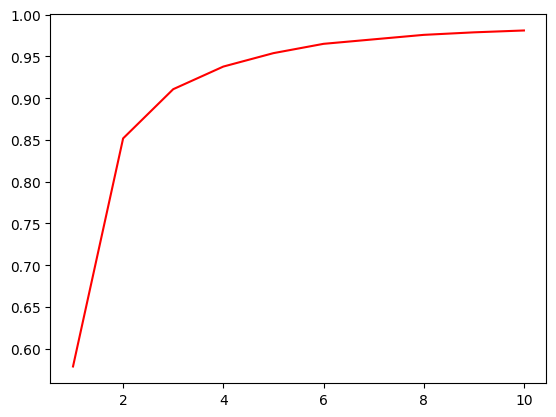

In [63]:
# Training accuracy
plt.plot(epochs, training_history.history["accuracy"], color="red", label="Training Accuracy")

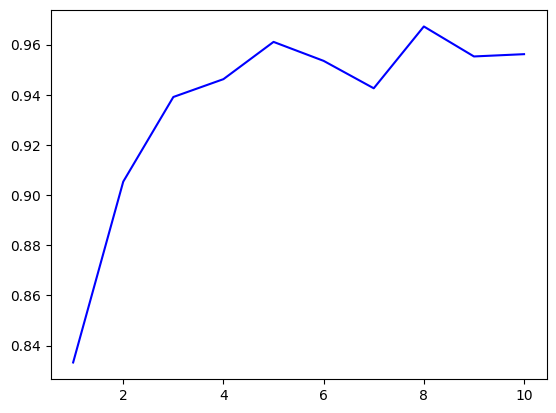

In [66]:
# Validation accuracy
plt.plot(epochs, training_history.history["val_accuracy"], color="blue", label="Validation Accuracy")

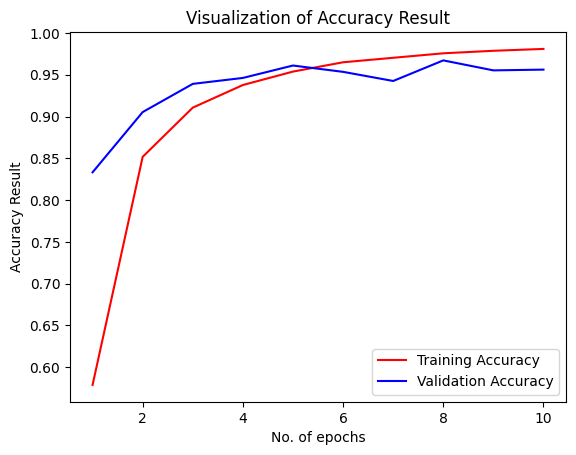

In [68]:
plt.plot(epochs, training_history.history["accuracy"], color="red", label="Training Accuracy")
plt.plot(epochs, training_history.history["val_accuracy"], color="blue", label="Validation Accuracy")
plt.xlabel("No. of epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

In [69]:
# Precision Recall and F1 Score
class_name = validation_set.class_names
class_name

['Apple Black Rot',
 'Apple Cedar Apple Rust',
 'Apple Healthy',
 'Apple Scab',
 'Blueberry Healthy',
 'Cherry(including sour) Healthy',
 'Cherry(including sour) Powdery Mildew',
 'Corn(maize) Cercospora Leaf Spot Gray Leaf Spot',
 'Corn(maize) Common Rust',
 'Corn(maize) Healthy',
 'Corn(maize) Northern Leaf Blight',
 'Grape Black Rot',
 'Grape Esca (Black Measles)',
 'Grape Healthy',
 'Grape Leaf Blight (Isariopsis Leaf Spot)',
 'Orange Haunglongbing (Citrus greening)',
 'Peach Bacterial Spot',
 'Peach Healthy',
 'Pepper Bell Bacterial Spot',
 'Pepper Bell Healthy',
 'Potato Early Blight',
 'Potato Healthy',
 'Potato Late Blight',
 'Raspberry Healthy',
 'Soybean Healthy',
 'Squash Powdery Mildew',
 'Strawberry Healthy',
 'Strawberry Leaf Scorch',
 'Tomato Bacterial Spot',
 'Tomato Early Blight',
 'Tomato Healthy',
 'Tomato Late Blight',
 'Tomato Leaf Mold',
 'Tomato Mosaic Virus',
 'Tomato Septoria Leaf Spot',
 'Tomato Spider Mites Two-spotted Spider Mite',
 'Tomato Target Spot',
 'T

In [70]:
test_set = tf.keras.utils.image_dataset_from_directory(
    "C:/Users/Aadarsh/Desktop/Plantix/data/valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [73]:
y_pred = model.predict(test_set)

550/550 [==============================] - 17s 31ms/step


In [74]:
y_pred

array([[1.00000000e+00, 3.77436927e-12, 4.79503881e-10, ...,
        1.07323581e-16, 4.15058308e-14, 6.95636892e-18],
       [9.99789894e-01, 2.36380426e-09, 9.87160789e-08, ...,
        2.62468338e-14, 2.36309194e-09, 9.64880387e-15],
       [1.00000000e+00, 1.24346814e-20, 8.56857165e-24, ...,
        8.11498105e-30, 4.82997293e-22, 1.03127459e-31],
       ...,
       [2.77355761e-09, 3.83675935e-09, 6.97258747e-06, ...,
        1.12683011e-07, 3.34901301e-07, 1.27530336e-01],
       [6.59245000e-23, 1.94743649e-18, 8.52204811e-18, ...,
        6.02052003e-15, 3.70725357e-15, 1.00000000e+00],
       [1.02981611e-16, 3.81386519e-13, 2.76321832e-14, ...,
        1.90744109e-09, 5.31721715e-11, 1.00000000e+00]], dtype=float32)

In [75]:
y_pred.shape

(17572, 38)

In [76]:
predicted_categories = tf.argmax(y_pred, axis=1)

In [84]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 28, 37, 37], dtype=int64)>

In [79]:
true_categories = tf.concat([y for x,y in test_set], axis=0)

In [80]:
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [81]:
Y_true = tf.argmax(true_categories, axis=1)

In [82]:
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [87]:
print(classification_report(Y_true, predicted_categories, target_names=class_name))

                                                 precision    recall  f1-score   support

                                Apple Black Rot       0.96      0.99      0.97       497
                         Apple Cedar Apple Rust       0.99      0.93      0.96       440
                                  Apple Healthy       0.86      0.98      0.92       502
                                     Apple Scab       0.96      0.97      0.96       504
                              Blueberry Healthy       0.96      0.96      0.96       454
                 Cherry(including sour) Healthy       0.97      0.99      0.98       456
          Cherry(including sour) Powdery Mildew       0.95      0.99      0.97       421
Corn(maize) Cercospora Leaf Spot Gray Leaf Spot       0.92      0.96      0.94       410
                        Corn(maize) Common Rust       0.99      1.00      0.99       477
                            Corn(maize) Healthy       1.00      0.99      0.99       465
               Corn(

In [90]:
conf_matrix = confusion_matrix(Y_true, predicted_categories)

In [91]:
conf_matrix.shape

(38, 38)

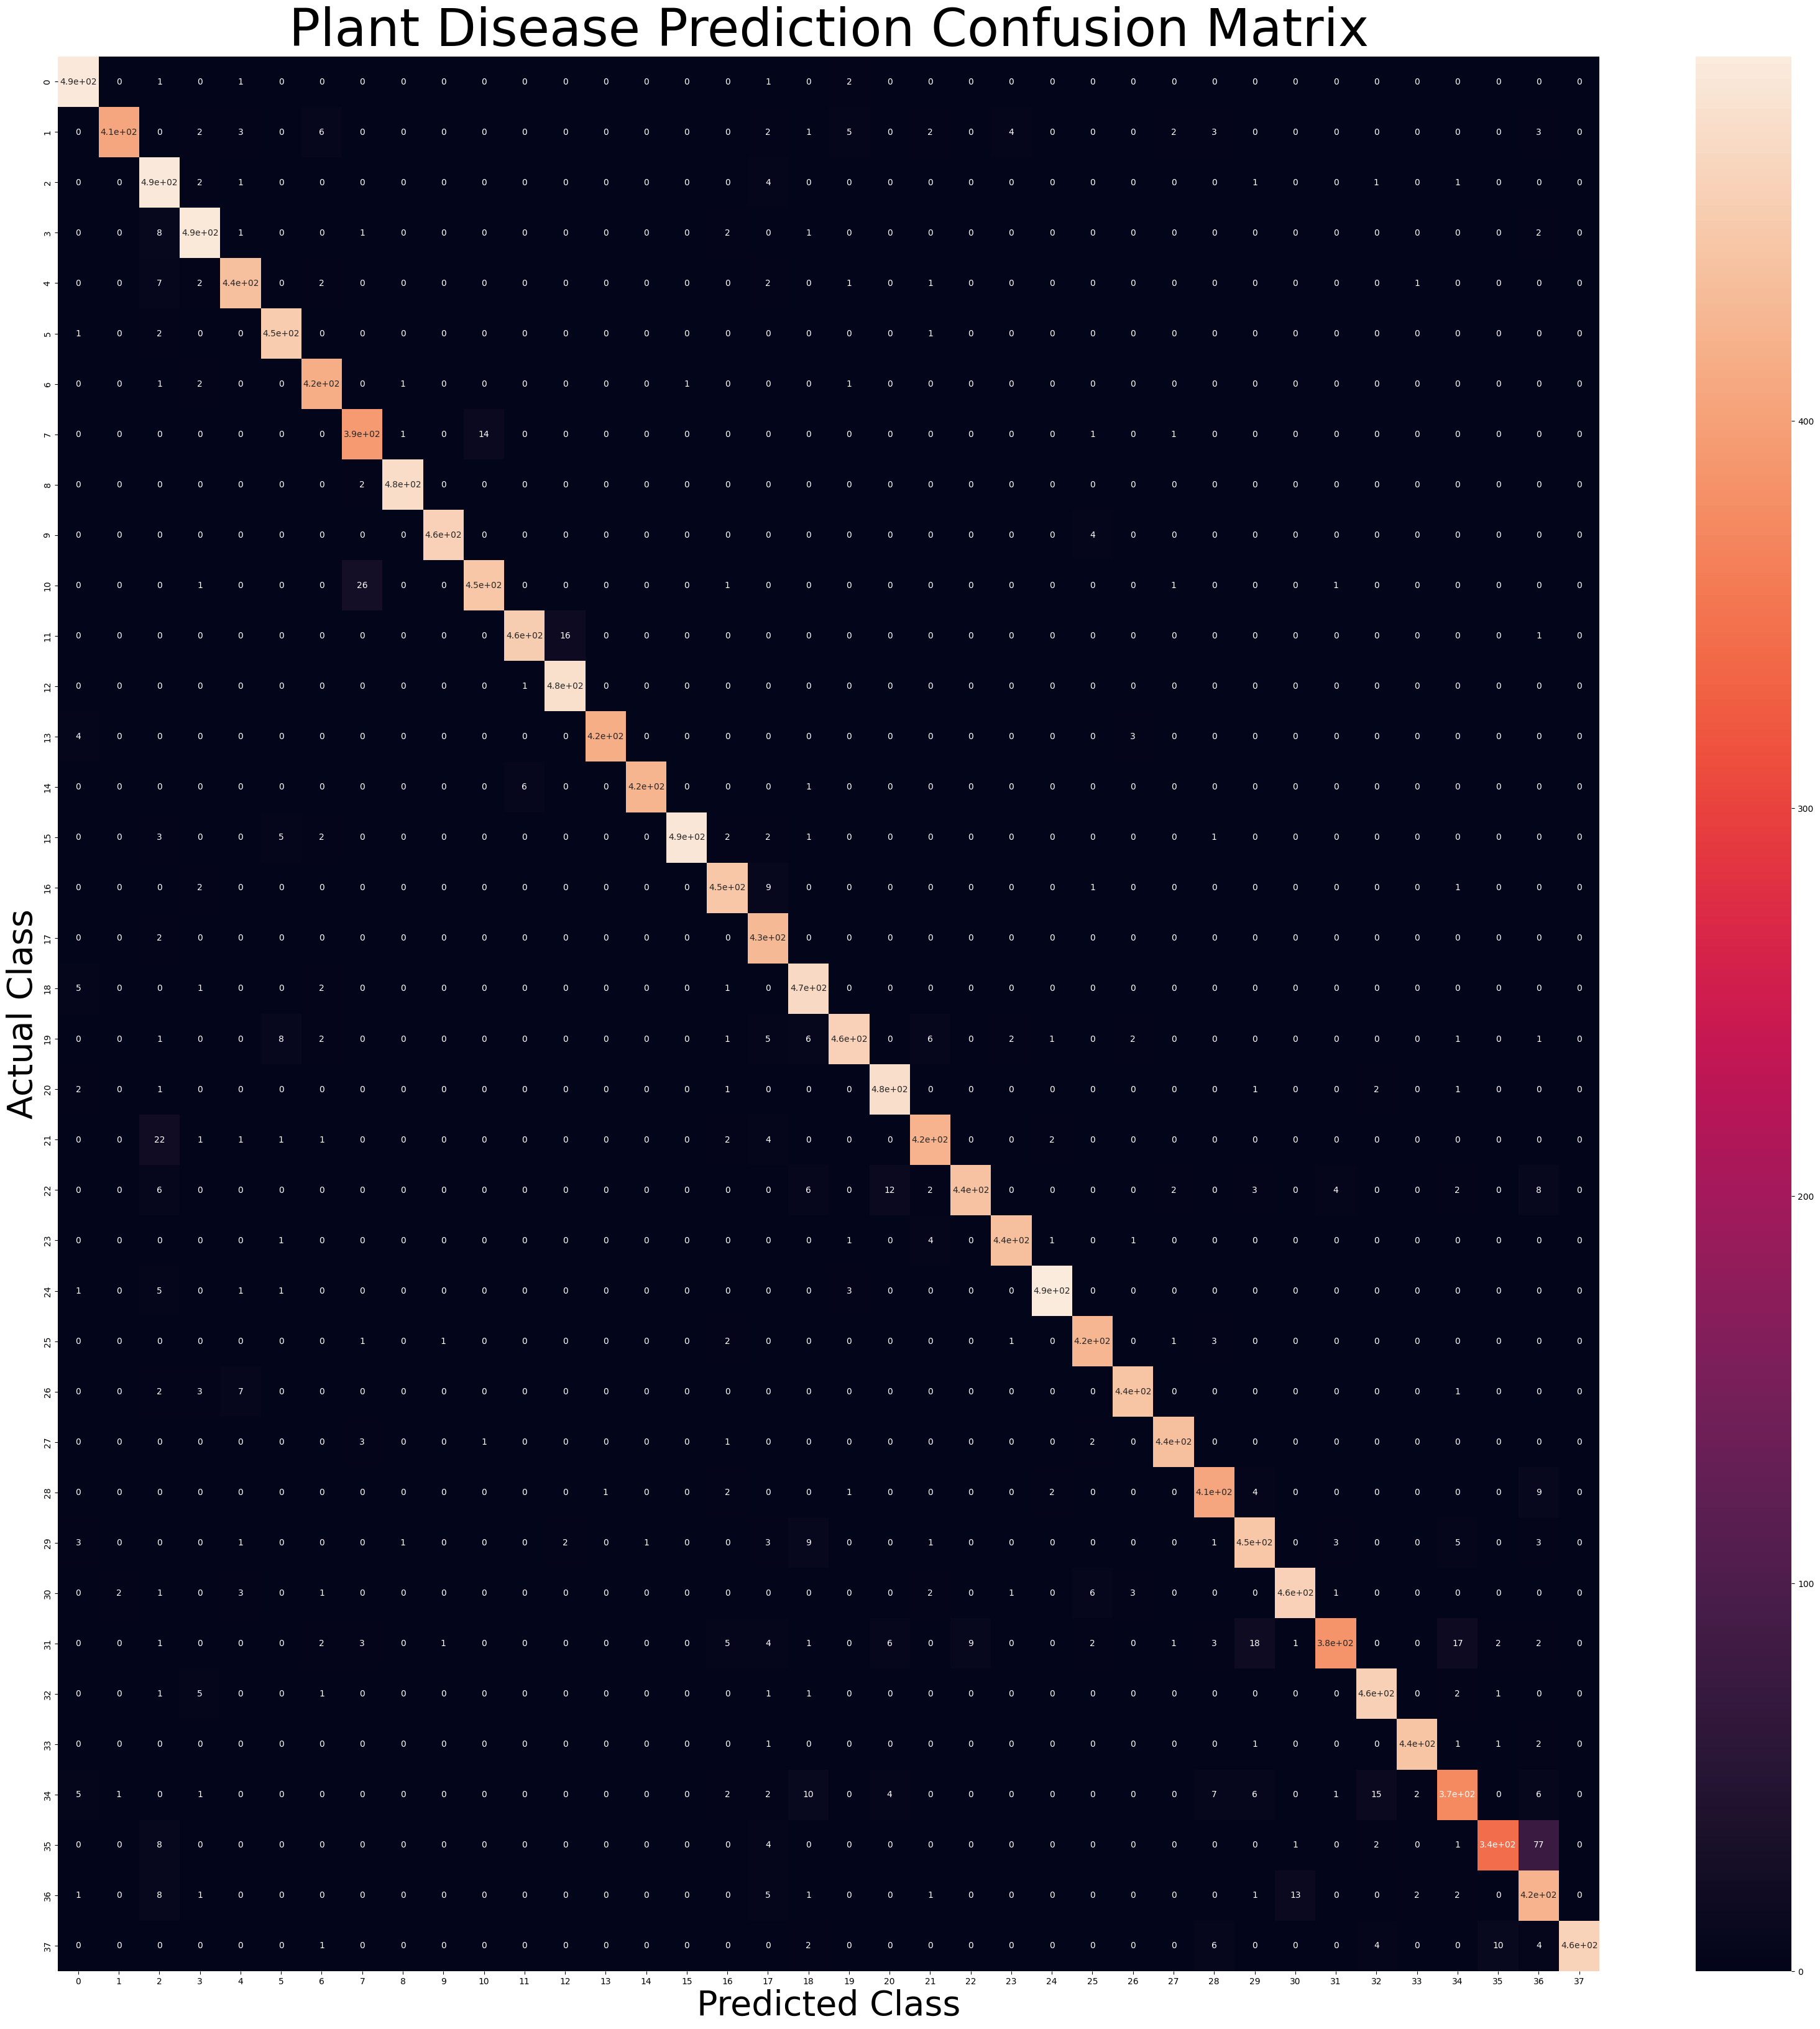

In [97]:
# Confusion Matrix visualization
plt.figure(figsize=(40, 40))
sns.heatmap(conf_matrix, annot=True, annot_kws={"size":10})
plt.xlabel("Predicted Class", fontsize=40)
plt.ylabel("Actual Class", fontsize=40)
plt.title("Plant Disease Prediction Confusion Matrix", fontsize=60)
plt.show()